In [1]:
import psycopg as pg
from psycopg.rows import dict_row
import pickle
import csv
import json
import pandas as pd
from tabulate import tabulate
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
from matplotlib.collections import LineCollection
import matplotlib.colors as mcol
import matplotlib.cm as cm
from matplotlib.dates import date2num, AutoDateLocator, ConciseDateFormatter, MinuteLocator
import plotly.express as px

import folium
import shapely as shp
import geopandas as gpd
from shapely.ops import transform
from shapely import wkb
from shapely.plotting import plot_polygon, plot_line
from pyproj import Proj, Transformer
import contextily as ctx

import datetime as dt
import pytz
import zoneinfo
import numpy as np
from math import atan2, degrees, ceil
import random
import itertools
import copy

In [2]:
def view_calibrations(location_id):
    with pg.connect(host='10.80.3.22', dbname='NDOT', user='lidar_reader', password='lidarread79246062') as conn:
        with conn.cursor() as cur:
            cur.execute("""
                SELECT loc.install_id, loc.utm_x, loc.utm_y, loc.location_description AS loc_descr,
                    loc.valid_start_dt AS location_start_dt, loc.valid_end_dt AS location_end_dt,
                    cal.shift_x, cal.shift_y, cal.rotation,
                    cal.valid_start_dt AS location_start_dt, cal.valid_end_dt AS location_end_dt
                FROM laddms.install_locations AS loc
                INNER JOIN laddms.install_calibration AS cal
                ON loc.install_id = cal.install_id
                    AND loc.valid_start_dt <= cal.valid_start_dt 
                    AND (loc.valid_end_dt >= cal.valid_end_dt OR (loc.valid_end_dt IS NULL AND cal.valid_end_dt IS NULL))
                WHERE loc.install_id = %(location_id)s""", 
                        {'location_id': location_id})
            rows = cur.fetchall()
            colnames = [desc[0] for desc in cur.description]
    
        # Format datetime columns to readable strings
        formatted_rows = []
        for row in rows:
            formatted_row = []
            for item in row:
                if isinstance(item, dt.datetime):
                    formatted_row.append(item.strftime("%Y-%m-%d %H:%M:%S"))
                else:
                    formatted_row.append(item)
            formatted_rows.append(formatted_row)
        
        # Print the table using column names from the query
        print(tabulate(formatted_rows, headers=colnames, tablefmt='psql'))

In [3]:
def get_trajectories(dt_start, dt_end, location_id):
    if dt_start.tzinfo is None or dt_end.tzinfo is None:
        raise ValueError("dt_start and dt_end must be timezone aware datetime objects.")
    with pg.connect(host='10.80.3.22', dbname='NDOT', user='lidar_reader', password='lidarread79246062') as conn:
        with conn.cursor(row_factory=dict_row) as cur:
            cur.execute("""
                SELECT loc.install_id, loc.utm_x, loc.utm_y, loc.location_description AS loc_descr,
                    loc.valid_start_dt AS location_start_dt, loc.valid_end_dt AS location_end_dt,
                    cal.shift_x, cal.shift_y, cal.rotation,
                    cal.valid_start_dt AS location_start_dt, cal.valid_end_dt AS location_end_dt
                FROM laddms.install_locations AS loc
                INNER JOIN laddms.install_calibration AS cal
                ON loc.install_id = cal.install_id
                    AND loc.valid_start_dt <= cal.valid_start_dt 
                    AND (loc.valid_end_dt >= cal.valid_end_dt OR (loc.valid_end_dt IS NULL AND cal.valid_end_dt IS NULL))
                WHERE loc.valid_start_dt <= %(dt_start)s AND 
                	cal.valid_start_dt <= %(dt_start)s AND
                	(loc.valid_end_dt IS NULL OR loc.valid_end_dt >= %(dt_end)s) AND
                	(cal.valid_end_dt IS NULL OR cal.valid_end_dt >= %(dt_end)s)""", 
                        {'dt_start': dt_start, 'dt_end': dt_end})
            install_cal = {r['install_id']: r for r in cur.fetchall()}
            if location_id not in install_cal:
                print(install_cal)
                raise ValueError(f"Didn't find calibration values for location={location_id} with time bounds {dt_start}-{dt_end}.")
        
        with conn.cursor(row_factory=dict_row) as cur:
            cur.execute("""
                SELECT object_id, intersection_id, classification, sub_classification,
                	AVG(length) AS obj_length, AVG(width) AS obj_width, AVG(height) AS obj_height,
                	ARRAY_AGG(frame_timestamp_dt ORDER BY frame_timestamp_dt) AS ts, 
                    ARRAY_AGG(position_x ORDER BY frame_timestamp_dt) AS obj_x, 
                    ARRAY_AGG(position_y ORDER BY frame_timestamp_dt) AS obj_y, 
                	ARRAY_AGG(velocity_x ORDER BY frame_timestamp_dt) AS vel_x, 
                    ARRAY_AGG(velocity_y ORDER BY frame_timestamp_dt) AS vel_y,
                    ARRAY_AGG(heading ORDER BY frame_timestamp_dt) AS heading
                FROM laddms.object_detections
                WHERE frame_timestamp_dt BETWEEN %(dt_start)s AND %(dt_end)s
                    AND intersection_id = %(loc_id)s
                GROUP BY object_id, intersection_id, classification, sub_classification;""",
                       {'dt_start': dt_start, 'dt_end': dt_end, 'loc_id': location_id})
            raw = cur.fetchall()

    # pre-fetch values for single location_id
    ical = install_cal[location_id]
    theta_deg = ical['rotation']
    theta = np.radians(theta_deg)  # Convert to radians
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    shift_x = ical['shift_x']
    shift_y = ical['shift_y']
    loc_utm_x = ical['utm_x']
    loc_utm_y = ical['utm_y']
    
    transformed_data = []
    print("{} trajectories to process".format(len(raw)))
    for i, traj in enumerate(raw):
        if len(traj['obj_x']) < 20:
            continue
        local_x = cos_theta * np.array(traj['obj_x']) - sin_theta * np.array(traj['obj_y']) + shift_x
        local_y = sin_theta * np.array(traj['obj_x']) + cos_theta * np.array(traj['obj_y']) + shift_y
        local_heading = [theta_deg + rot for rot  in traj["heading"]]
        utm_x = local_x + loc_utm_x
        utm_y = local_y + loc_utm_y
        transformed_data.append({**traj, **{'utm_x': utm_x, 'utm_y': utm_y, 'rot_heading':local_heading}})
    return transformed_data

In [4]:
def get_time_index(dt_start, dt_end, location_id):
    if dt_start.tzinfo is None or dt_end.tzinfo is None:
        raise ValueError("dt_start and dt_end must be timezone aware datetime objects.")
    with pg.connect(host='10.80.3.22', dbname='NDOT', user='lidar_reader', password='lidarread79246062') as conn:
        cur = conn.cursor(row_factory=dict_row)
        cur.execute("""
            SELECT frame_timestamp_dt,
            	ARRAY_AGG(object_id ORDER BY object_id) AS obj_id,
                ARRAY_AGG(classification ORDER BY object_id) AS obj_class,
            	ARRAY_AGG(position_x ORDER BY object_id) AS obj_x, 
            	ARRAY_AGG(position_y ORDER BY object_id) AS obj_y, 
            	ARRAY_AGG(velocity_x ORDER BY object_id) AS obj_vx, 
            	ARRAY_AGG(velocity_y ORDER BY object_id) AS obj_vy,
            	ARRAY_AGG(length ORDER BY object_id) AS obj_l,
            	ARRAY_AGG(width ORDER BY object_id) AS obj_w,
            	ARRAY_AGG(height ORDER BY object_id) AS obj_h
            FROM laddms.object_detections
            WHERE frame_timestamp_dt >= %(dt_start)s AND frame_timestamp_dt < %(dt_end)s
            	AND intersection_id = %(loc_id)s
            GROUP BY frame_timestamp_dt
            ORDER BY frame_timestamp_dt ASC;""",
                   {'dt_start': dt_start, 'dt_end': dt_end, 'loc_id': location_id})
        raw = cur.fetchall()
    return raw

In [5]:
def trajectories_to_linestrings(trajectories):
    return [shp.geometry.LineString([(x, y) for x, y in zip(traj['utm_x'], traj['utm_y'])]) 
            for traj in trajectories]

In [6]:
def plot_trajectories_map(linestrings, polygons_geodataframe=None, save_html_filepath=None, polygon_color_dict=None):
    if len(linestrings) == 0:
        print("NO DATA TO PLOT")
        return None
    gdf = gpd.GeoDataFrame(geometry=linestrings, crs="EPSG:32616")  # UTM Zone 16N
    gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.25)
    gdf_wgs84 = gdf.to_crs(epsg=4326)
    
    def random_color():
        return f'#{random.randint(0, 0xFFFFFF):06x}'

    def polygon_style_function(feature):
        id_value = feature['properties']['id']
        if polygon_color_dict is None:
            return {'fillColor': 'red', 'color': 'black', 'weight': 1.5, 'fillOpacity': 0.5}
        else:
            return {'fillColor': polygon_color_dict[id_value], 'color': 'black', 'weight': 1.5, 'fillOpacity': 0.5}
    
    # Create a folium map centered on the first polygon
    centroid = gdf_wgs84.geometry.centroid.iloc[0]
    m = folium.Map(location=[centroid.y, centroid.x], zoom_start=12)

    if polygons_geodataframe is not None:
        # for _, row in polygons_geodataframe.iterrows():
        #     sim_geo = gpd.GeoSeries(row['geometry'])
        #     geo_j = sim_geo.to_json()
        #     this_color = copy.copy(polygon_color_dict[row['id']])
        #     geo_json = folium.GeoJson(data=geo_j,
        #                               style_function=lambda x: {'color': polygon_color_dict, 'fillOpacity': 0.2})
        #     geo_json.add_to(m)
        folium.GeoJson(polygons_geodataframe,
                       style_function=polygon_style_function
                      ).add_to(m)
    
    # Add the lines to the folium map
    for _, row in gdf_wgs84.iterrows():
        sim_geo = gpd.GeoSeries(row['geometry'])
        geo_j = sim_geo.to_json()
        geo_json = folium.GeoJson(data=geo_j,
                                  style_function=lambda x, color=random_color(): {'color': color, 'weight': 1.5})
        geo_json.add_to(m)
    
    # Save the map to an HTML file and display it in the notebook
    if save_html_filepath is not None:
        m.save(save_html_filepath)

    return m

In [7]:
def filter_vehicles(trajectory_dicts):
    filtered = []
    non_class_count = 0
    small_count = 0
    for t in trajectory_dicts:
        if t['classification'] in ('VEHICLE', 'LARGE_VEHICLE'):
            if t['obj_length'] + t['obj_width'] + t['obj_height'] > 4:
                filtered.append(t)
            else:
                small_count += 1
        else:
            non_class_count += 1
    print("Non-vehicle class filter:", non_class_count)
    print("Vehicle size filter:", small_count)
    return filtered

In [8]:
def filter_persons(trajectory_dicts):
    filtered = []
    for t in trajectory_dicts:
        if t['classification'] in ('PERSON',):
            filtered.append(t)
    return filtered

In [9]:
def filter_bikes(trajectory_dicts):
    filtered = []
    for t in trajectory_dicts:
        if t['classification'] in ('BICYCLE',):
            filtered.append(t)
    return filtered

In [10]:
def filter_distance_covered(trajectory_dicts, distance_threshold):
    filtered = []
    short_count = 0
    for t in trajectory_dicts:
        if len(t['utm_x']) >= 2:
            if ((t['utm_x'][0] - t['utm_x'][-1]) ** 2 + (t['utm_y'][0] - t['utm_y'][-1]) ** 2) ** 0.5 >= distance_threshold:
                filtered.append(t)
            else:
                short_count += 1
        else:
            short_count += 1
    print("Short distance filter:", short_count)
    return filtered

In [48]:
def count_trajectory_intersections(polygons, trajectories):
    """
    Count how many times each polygon is intersected by trajectories,
    and identify movements by checking each possible (start, end) zone pair
    within the full zone_hits sequence (order-only match).
    
    Parameters:
    - polygons: List of tuples (id, name, polygon_object) where polygon_object is a Shapely Polygon.
    - trajectories: List of dicts, each with keys 'utm_x', 'utm_y', and 'ts' (list of datetime stamps).

    Returns:
    - intersection_counts, intersection_counts_by_hour, intersection_counts_by_15m,
      movement_counts, movement_counts_by_hour, movement_counts_by_15m
    """

    def new_zone_dict():
        return {poly_id: 0 for poly_id, _ in polygons}

    def new_mvmt_dict():
        return {perm: 0 for perm in itertools.permutations(intersection_counts.keys(), 2)}

    intersection_counts = new_zone_dict()
    intersection_counts_by_hour = {}
    intersection_counts_by_15m = {}

    movement_counts = new_mvmt_dict()
    movement_counts_by_hour = {}
    movement_counts_by_15m = {}
    one_hits = 0
    multi_hits = 0

    for traj in trajectories:
        zone_hits = []

        # Sample every 5th point: convert zip to list to allow slicing
        pts = list(zip(traj['utm_x'], traj['utm_y']))
        traj_pts = [shp.Point(x, y) for x, y in pts[::5]]

        traj_hour = traj['ts'][0].hour
        traj_minute = traj['ts'][0].minute
        quant_min = (traj_minute // 15) * 15
        traj_15m = dt.time(hour=traj_hour, minute=quant_min)

        # Initialize counts by time buckets
        intersection_counts_by_hour.setdefault(traj_hour, new_zone_dict())
        movement_counts_by_hour.setdefault(traj_hour, new_mvmt_dict())
        intersection_counts_by_15m.setdefault(traj_15m, new_zone_dict())
        movement_counts_by_15m.setdefault(traj_15m, new_mvmt_dict())

        # Build zone_hits sequence (no consecutive duplicates)
        for pt in traj_pts:
            for poly_id, polygon in polygons:
                if polygon.contains(pt):
                    if not zone_hits or zone_hits[-1] != poly_id:
                        zone_hits.append(poly_id)
                    break

        # Count zone intersections
        for zi in zone_hits:
            intersection_counts[zi] += 1
            intersection_counts_by_hour[traj_hour][zi] += 1
            intersection_counts_by_15m[traj_15m][zi] += 1

        # Identify movements: order-only match for all zone pairs
        for mv in movement_counts:
            start_z, end_z = mv
            try:
                if zone_hits.index(start_z) < zone_hits.index(end_z):
                    movement_counts[mv] += 1
                    movement_counts_by_hour[traj_hour][mv] += 1
                    movement_counts_by_15m[traj_15m][mv] += 1
            except ValueError:
                continue

        # Track counts for single- and multi-zone-only hits
        if len(zone_hits) == 1:
            one_hits += 1
        elif len(zone_hits) > 1:
            multi_hits += 1
    #Error percentage to find how much data is missing
    error_perct = (one_hits/(one_hits+multi_hits))*100
    print(f"Had {one_hits}x single zone hits and {multi_hits}x multiple-zone hits.")
    print(f"Error Percentage: {error_perct}%")
    return (
        intersection_counts,
        intersection_counts_by_hour,
        intersection_counts_by_15m,
        movement_counts,
        movement_counts_by_hour,
        movement_counts_by_15m
    )


Zone 323: 10, D, ClarksvilleHS
Zone 324: 10, D, ClarksvilleHS
Zone 329: 10, C, Richview Rd
Zone 328: 10, D, Cunningham
Zone 395: 10, C, Cunningham
Zone 396: 10, B, Cunningham
Zone 397: 10, A, Glenkirk
Zone 398: 10, A, Glenkirk
Zone 331: 10, B, None
Zone 325: 10, None, Cunningham
Zone 326: 10, C, Cunningham
Zone 327: 10, B, Cunningham
Zone 332: 10, B, None
Zone 333: 10, B, None
Zone 334: 10, D, Richview Rd 
Zone 335: 10, A, Spings
Zone 336: 10, A, Springs
Zone 337: 10, D, Springs
Zone 338: 10, D, Springs
Zone 339: 10, C, Springs
Zone 340: 10, C, Springs
Zone 341: 10, B, Springs
Zone 342: 10, C, Springs
Zone 343: 10, A, Purple Heart
Zone 344: 10, A, Purple Heart
Zone 345: 10, B, Purple Heart
Zone 346: 10, B, Purple Heart
Zone 347: 10, C, Purple Heart
Zone 348: 10, C, Purple Herat
Zone 349: 10, D, Purple Heart
Zone 350: 10, D, Purple Heart
Zone 330: 10, C, None
Zone 354: 10, C, Richview Rd 
Zone 399: 10, C, Providence
Zone 351: 10, A, Richview Rd
Zone 352: 10, A, Richview Rd
Zone 353: 10,

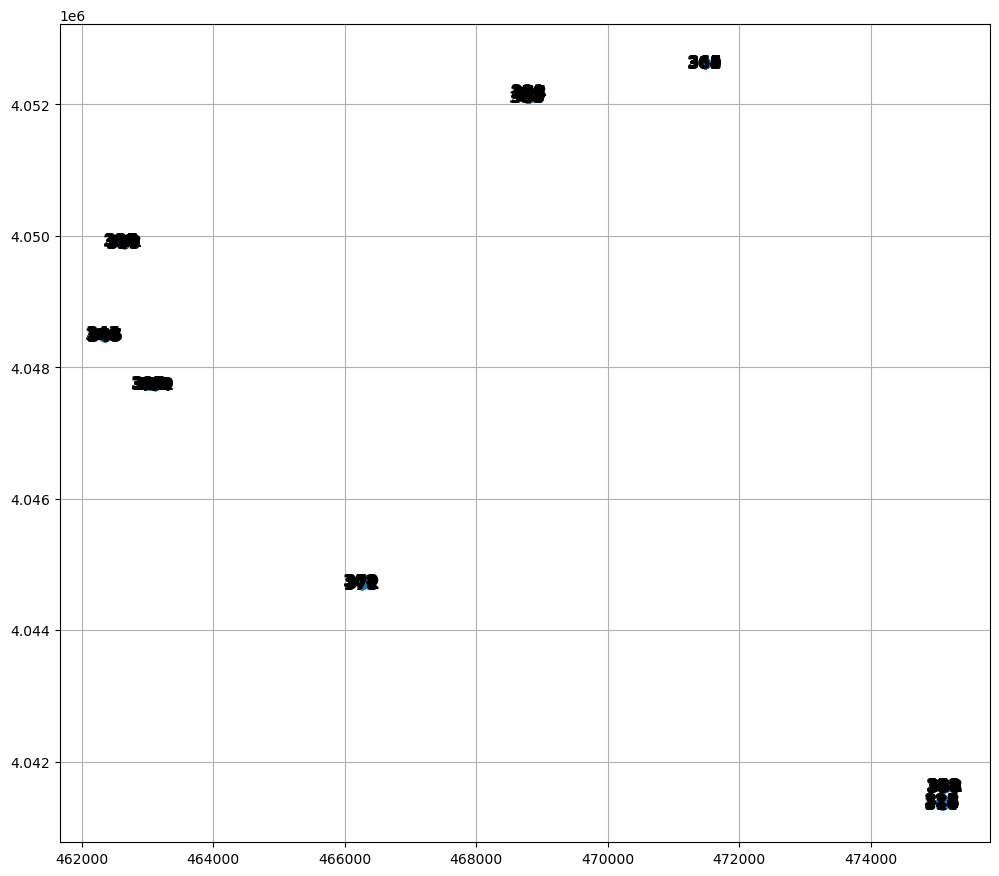

In [49]:
with pg.connect(host='10.80.3.22', dbname='NDOT', user='lidar_reader', password='lidarread79246062') as conn:
        with conn.cursor() as cur:
            cur.execute("""
                SELECT zid, install_id, approach_segment, approach_road_name, zone_type, geom, approach_direction
                FROM laddms.zones
                WHERE install_id = 10;
            """)
            # Fetch all rows
            rows = cur.fetchall()
            # Get column names (in same order as fetchall)
            colnames = [desc[0] for desc in cur.description]

# Build dictionary with zid as keys
zones = {}
for row in rows:
    record = dict(zip(colnames, row))
    zid = record.pop('zid')
    # Convert geom (WKB) to shapely geometry
    geom_raw = record['geom']
    record['geom'] = wkb.loads(record['geom'], hex=isinstance(geom_raw, str))
    record['name'] = f"{record['approach_segment']}_{record['approach_road_name']}_{record['zone_type']}_{record['approach_direction']}"
    zones[zid] = record

# Output the converted shapes
for idx, data in zones.items():
    print(f"Zone {idx}: {data['install_id']}, {data['approach_segment']}, {data['approach_road_name']}")

plt.figure(figsize=(12, 12))
for pid, z in zones.items():
    plot_polygon(z['geom'])
    centroid = z['geom'].centroid
    centroid_x, centroid_y = centroid.x, centroid.y
    plt.text(centroid_x, centroid_y, str(pid), fontsize=12, ha="center", va="center", color="black", weight="bold")

plt.show()

In [50]:
def process_all_locations(location_data, zones, get_trajectories, filter_persons, filter_vehicles,
                          filter_distance_covered, count_trajectory_intersections, plot_polygon):


    for name, dtbounds, veh_mvmt_zones, ped_zone_ids in location_data:
        start_dt = dt.datetime.strptime(dtbounds[0], "%Y-%m-%d %H:%M:%S").replace(tzinfo=zoneinfo.ZoneInfo('US/Central'))
        end_dt = dt.datetime.strptime(dtbounds[1], "%Y-%m-%d %H:%M:%S").replace(tzinfo=zoneinfo.ZoneInfo('US/Central'))

        first_day = (start_dt + dt.timedelta(days=1)).replace(hour=0, minute=0, second=0, microsecond=0)
        last_day = (end_dt - dt.timedelta(days=1)).replace(hour=0, minute=0, second=0, microsecond=0)

        os.makedirs(name, exist_ok=True)

        current_day = first_day
        while current_day <= last_day:
            day_start = current_day
            day_end = current_day.replace(hour=23, minute=59, second=59, microsecond=999999)
            print(f"\n\n >>> Time bounds: {day_start} → {day_end}\n")
            date_string = day_start.date().strftime("%Y-%m-%d")

            data = get_trajectories(day_start, day_end, location_id=10)
            classes = [d['classification'] for d in data]
            counts = {cl: classes.count(cl) for cl in set(classes)}
            print("Classification count:", counts)

            people = filter_distance_covered(filter_persons(data), distance_threshold=10)
            vehicles = filter_distance_covered(filter_vehicles(data), distance_threshold=12)
            print(f"Total persons, distance filtered: {len(people)}")
            print(f"Total vehicles, distance filtered: {len(vehicles)}")

            veh_zone_ids = set(elem for tup in veh_mvmt_zones.values() for elem in tup)
            veh_zones = [(pid, z['geom']) for pid, z in zones.items() if pid in veh_zone_ids]
            ped_zones = [(pid, z['geom']) for pid, z in zones.items() if pid in ped_zone_ids]

            fig, ax = plt.subplots(1, 1, figsize=(12, 8))
            for pid, z in veh_zones:
                plot_polygon(z)
            for traj in vehicles[::25]:
                plt.plot(traj['utm_x'][::10], traj['utm_y'][::10], alpha=0.11)
            plt.axis('equal')
            plt.savefig(f"{name}/{name}_{date_string}_veh.png", transparent=True)
            plt.close()

            fig, ax = plt.subplots(1, 1, figsize=(12, 8))
            for pid, z in ped_zones:
                plot_polygon(z)
            for traj in people[::20]:
                plt.plot(traj['utm_x'][::10], traj['utm_y'][::10], alpha=0.11)
            plt.axis('equal')
            plt.savefig(f"{name}/{name}_{date_string}_ped.png", transparent=True)
            plt.close()

            zone_counts, zone_counts_hours, zone_counts_15m, movement_counts, movement_counts_hours, movement_counts_15m = count_trajectory_intersections(veh_zones, vehicles)

            print("\nVehicle zone results")
            for movement_name, (zid1, zid2, _, _) in veh_mvmt_zones.items():
                print(movement_name, ":", movement_counts.get((zid1, zid2), 0))

            hour_list = list(sorted(movement_counts_hours.keys()))
            row_list = []
            for movement_name, (zid1, zid2, _, _) in veh_mvmt_zones.items():
                by_hour = [movement_counts_hours[hr].get((zid1, zid2), 0) for hr in hour_list]
                row_dict = dict(zip(['movement'] + hour_list, [movement_name] + by_hour))
                row_list.append(row_dict)
            df_hours = pd.DataFrame(row_list)
            df_hours['movement_total'] = df_hours.drop('movement', axis=1).sum(axis=1)
            df_hours.to_csv(f"{name}/{name}_{date_string}_veh_hourly_movements.csv", index=False)

            m15_list = list(sorted(movement_counts_15m.keys()))
            m15_text = [m.strftime('%H:%M') for m in m15_list]
            row_list = []
            for movement_name, (zid1, zid2, _, _) in veh_mvmt_zones.items():
                by_interval = [movement_counts_15m[m].get((zid1, zid2), 0) for m in m15_list]
                row_dict = dict(zip(['movement'] + m15_text, [movement_name] + by_interval))
                row_list.append(row_dict)
            df_15m = pd.DataFrame(row_list)
            df_15m['movement_total'] = df_15m.drop('movement', axis=1).sum(axis=1)
            df_15m.to_csv(f"{name}/{name}_{date_string}_veh_15m_movements.csv", index=False)

            zone_counts, zone_counts_hours, zone_counts_15m, _, _, _ = count_trajectory_intersections(ped_zones, people)
            print("\nPedestrian zone results")
            for zi in ped_zone_ids:
                print(f"\t{zones[zi]['name']}: {zone_counts.get(zi, 0)}")

            hour_list = list(sorted(zone_counts_hours.keys()))
            row_list = []
            for zone_i, _ in zone_counts.items():
                by_hour = [zone_counts_hours[hr].get(zone_i, 0) for hr in hour_list]
                row_dict = dict(zip(['zone'] + hour_list, [zones[zone_i]['name']] + by_hour))
                row_list.append(row_dict)
            df_hours = pd.DataFrame(row_list)
            df_hours['zone_total'] = df_hours.drop('zone', axis=1).sum(axis=1)
            if 'zone' in df_hours.columns:  # safe drop
                df_hours = df_hours.drop(columns=['zone'])
            df_hours.to_csv(f"{name}/{name}_{date_string}_ped_hourly_hits.csv", index=False)

            m15_list = list(sorted(zone_counts_15m.keys()))
            m15_text = [m.strftime('%H:%M') for m in m15_list]
            row_list = []
            for zone_i, _ in zone_counts.items():
                by_15m = [zone_counts_15m[m].get(zone_i, 0) for m in m15_list]
                row_dict = dict(zip(['zone'] + m15_text, [zones[zone_i]['name']] + by_15m))
                row_list.append(row_dict)
            df_15m = pd.DataFrame(row_list)
            df_15m['zone_total'] = df_15m.drop('zone', axis=1).sum(axis=1)
            if 'zone' in df_15m.columns:  # safe drop
                df_15m = df_15m.drop(columns=['zone'])
            df_15m.to_csv(f"{name}/{name}_{date_string}_ped_15m_hits.csv", index=False)

            current_day += dt.timedelta(days=1)


## Input Zones zid for Location

In [51]:
# Cunningham Ln and Glenkirk Dr with Cunningham Ln and New Providence MS
loc1_veh_movement_keys = {
    'Providence_nb_lt': (404, 403),
    'Providence_nb_rt': (404, 401),
    'Cunningham_eb_th': (402, 401),
    'Cunningham_eb_rt': (402, 399),
    'Cunningham_wb_th': (400, 403),
    'Cunningham_wb_lt': (400, 399),
#2nd Intersection
    'Cunningham&Glen_eb_th': (328, 396),
    'Cunningham&Glen_eb_rt': (328, 326),
    'Cunningham&Glen_eb_lt': (328, 398),
    'Cunningham&Glen_wb_th': (327, 395),
    'Cunningham&Glen_wb_rt': (327, 398),
    'Cunningham&Glen_wb_lt': (327, 326),
    'Glenkirk_sb_th': (397, 326),
    'Glenkirk_sb_rt': (397, 395),
    'Glenkirk_sb_lt': (397, 396),
}
loc1_veh_movement_keys = {mn: (zn1, zn2, zones[zn1]['name'], zones[zn2]['name']) for mn, (zn1, zn2) in loc1_veh_movement_keys.items()}
print(loc1_veh_movement_keys)
loc1_ped_zones = [325]
loc1_dt = ("2025-05-13 14:00:00", "2025-05-29 05:00:00") #Total range

{'Providence_nb_lt': (404, 403, 'C_Providence_stopbar_in', 'D_Cunningham_stopbar_out'), 'Providence_nb_rt': (404, 401, 'C_Providence_stopbar_in', 'B_Cunningham_stopbar_out'), 'Cunningham_eb_th': (402, 401, 'D_Cunningham_stopbar_in', 'B_Cunningham_stopbar_out'), 'Cunningham_eb_rt': (402, 399, 'D_Cunningham_stopbar_in', 'C_Providence_stopbar_out'), 'Cunningham_wb_th': (400, 403, 'B_Cunningham_stopbar_in', 'D_Cunningham_stopbar_out'), 'Cunningham_wb_lt': (400, 399, 'B_Cunningham_stopbar_in', 'C_Providence_stopbar_out'), 'Cunningham&Glen_eb_th': (328, 396, 'D_Cunningham_stopbar_in', 'B_Cunningham_stopbar_out'), 'Cunningham&Glen_eb_rt': (328, 326, 'D_Cunningham_stopbar_in', 'C_Cunningham_stopbar_out'), 'Cunningham&Glen_eb_lt': (328, 398, 'D_Cunningham_stopbar_in', 'A_Glenkirk_stopbar_out'), 'Cunningham&Glen_wb_th': (327, 395, 'B_Cunningham_stopbar_in', 'C_Cunningham_stopbar_out'), 'Cunningham&Glen_wb_rt': (327, 398, 'B_Cunningham_stopbar_in', 'A_Glenkirk_stopbar_out'), 'Cunningham&Glen_wb_l

## Insert Specific Time for counts in "Total Range"

In [52]:
loc1_dt = ("2025-05-14 00:00:00", "2025-05-16 00:00:00")
location_data = [
    ('loc1', loc1_dt, loc1_veh_movement_keys, loc1_ped_zones),
]

In [53]:
process_all_locations(location_data, zones, get_trajectories, filter_persons, filter_vehicles,
                      filter_distance_covered, count_trajectory_intersections, plot_polygon)




 >>> Time bounds: 2025-05-15 00:00:00-05:00 → 2025-05-15 23:59:59.999999-05:00

330483 trajectories to process
Classification count: {'UNKNOWN': 158, 'PERSON': 9812, 'LARGE_VEHICLE': 1154, 'BICYCLE': 6105, 'VEHICLE': 36917}
Short distance filter: 7531
Non-vehicle class filter: 16075
Vehicle size filter: 0
Short distance filter: 23165
Total persons, distance filtered: 2281
Total vehicles, distance filtered: 14906
Had 1838x single zone hits and 10535x multiple-zone hits.
Error Percentage: 14.854926048654328%

Vehicle zone results
Providence_nb_lt : 73
Providence_nb_rt : 131
Cunningham_eb_th : 3720
Cunningham_eb_rt : 218
Cunningham_wb_th : 3902
Cunningham_wb_lt : 190
Cunningham&Glen_eb_th : 1949
Cunningham&Glen_eb_rt : 189
Cunningham&Glen_eb_lt : 210
Cunningham&Glen_wb_th : 2414
Cunningham&Glen_wb_rt : 215
Cunningham&Glen_wb_lt : 140
Glenkirk_sb_th : 10
Glenkirk_sb_rt : 332
Glenkirk_sb_lt : 148
Had 91x single zone hits and 0x multiple-zone hits.
Error Percentage: 100.0%

Pedestrian zone